In [ ]:
# Level 2 - Task 1: Predicting House Prices with Linear Regression

Objective: Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age.
This notebook covers the end-to-end workflow from data cleaning and exploratory data analysis (EDA) to model training, evaluation, and interpretation.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style for better visualizations
sns.set_theme(style="whitegrid")

In [ ]:
##  Load the Dataset and Initial Inspection
Let's load the dataset and look at the first few rows, the overall shape, and the data types.

In [2]:
# Load the dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Display dataset shape
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Display dataset information 
df.info()

# Show the first 5 rows
display(df.head())

Dataset Shape: 2000 rows and 10 columns.

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
##  Data Quality & Null Value Check
Next, we check if there are any missing values in the dataset that need to be handled before training our model.

In [3]:
# Check for null values in each column
null_counts = df.isnull().sum()
print("Missing Values per Column:")
print(null_counts)

Missing Values per Column:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [ ]:
As seen above, there are 0 missing values in this dataset. We do not need to perform any imputation. 

#  Descriptive Statistics
Let's look at the summary statistics for our numerical features to understand the scale and spread of the data.

In [4]:
# Generate descriptive statistics for numerical columns
display(df.describe())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
#Target Variable Distribution (Price)
The target variable we want to predict is Price. Let's visualize its distribution to see if it is skewed or normally distributed.

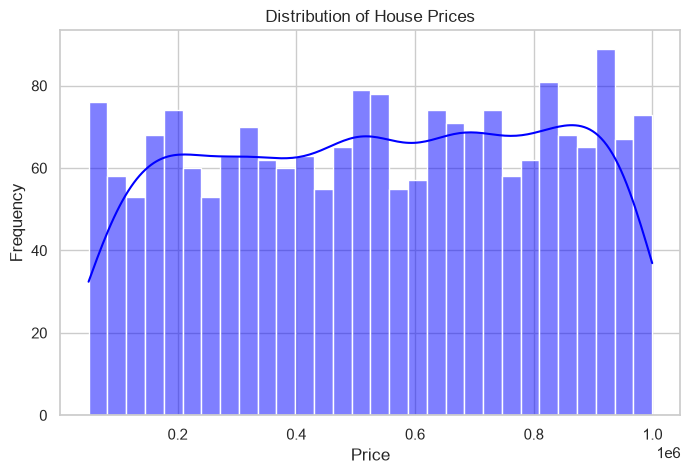

In [5]:
# Plot the distribution of the target variable 'Price'
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, bins=30, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Feature Selection Discussion & Data Preprocessing
Before modeling, we must decide which features to include. 
- Id: This is just a unique identifier for each row and carries no predictive power. It will be dropped.
- Numerical Features: Area, Bedrooms, Bathrooms, Floors, YearBuilt. These are standard predictive features for house prices and will be kept.
- Categorical Features: Location, Condition, Garage. Machine learning models require numerical input, so we must encode these categories.

We will use One-Hot Encoding (pd.get_dummie) to convert the categorical variables into binary (0 or 1) columns. 
We will also drop the first category of each feature to avoid multicollinearity (the "dummy variable trap").

In [6]:
# Drop the 'Id' column
df = df.drop(columns=['Id'])

# Encode categorical features using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Show the new columns after encoding
print("Columns after One-Hot Encoding:")
print(df_encoded.columns.tolist())
display(df_encoded.head())

Columns after One-Hot Encoding:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [ ]:
#Correlation Analysis & Heatmap
Now that all features are numeric, we can check how strongly they correlate with Price and with each other.
A correlation heatmap helps identify which features are likely to be good predictors.

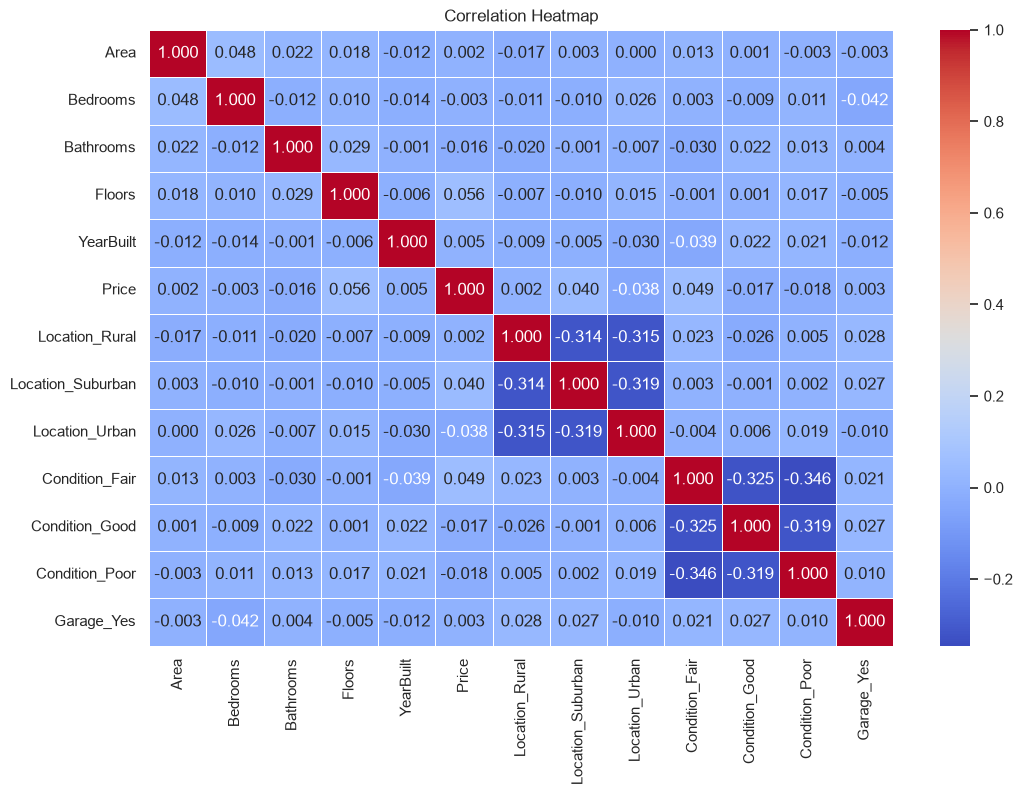

Correlation with Price:
Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


In [7]:
# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Print features most correlated with Price
print("Correlation with Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

In [ ]:
Observation: Looking at the correlation values with Price, all features in this specific dataset exhibit very low correlation (close to 0). 
This suggests that the dataset may be synthetically generated with high randomnes, and a linear model might struggle to capture a strong pattern. 
We will proceed with the regression to confirm this mathematicaly.

 # Train/Test Split
We will split the data into 80% training data and 20% testing data as requested by the assignment checklist.

In [8]:
# Define features (X) and target (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# Split the data into 80% train and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(1600, 12), y=(1600,)
Testing data shape: X=(400, 12), y=(400,)


In [ ]:
#Train the Linear Regression Model
We will instantiate and train a standard Linear Regression model using scikit-learn.

In [9]:
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model on the training data
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
##Model Evaluation
We will evaluate the model's performance on the test set using three metris:
- Mean Squared Error (MSE): The average squared difference between estimated values and actual value.
- Root Mean Squared Error (RMSE): The square root of MSE, putting the error in the same units as the target variable (Price).
- R² Score:The proportion of the variance in the dependent variable that is predictable from the independent variables.

In [10]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 78,321,466,146.03
Root Mean Squared Error (RMSE): 279,859.73
R² Score: -0.0067


In [ ]:
## Visualizing the Results

### Scatter Plot: Actual vs Predicted Prices
A perfect model would have all points falling on a straight diagonal line. Let's see how our predictions look.

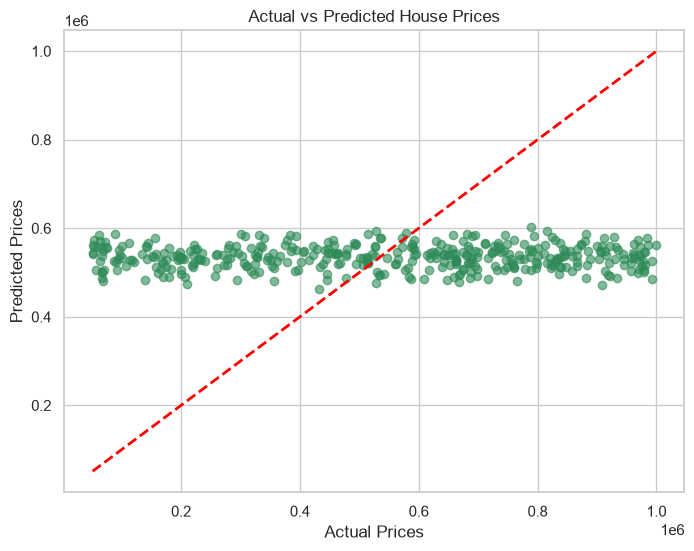

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='seagreen')

# Add a reference diagonal line for perfect predictions
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

In [ ]:
### Residual Plot
Residuals are the differences between the actual and predicted values ($y - \hat{y}$). 
Plotting residuals helps check if the model's errors are randomly distributed, which is an asumption of linear regrssion.

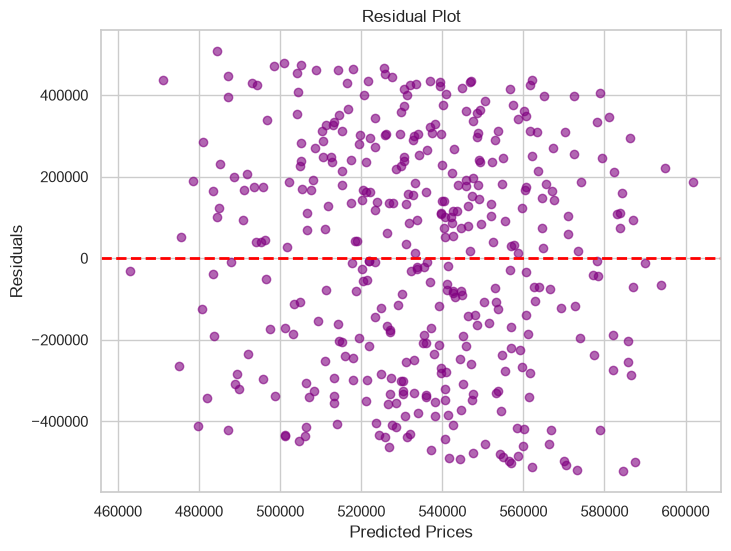

In [12]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')

# Add a horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.show()

In [ ]:
### Residual Interpretation
The residual plot shows a wide, scattered distribution without a clear geometric pattern, which usually implies that linear regression assumptions 
(like homoscedasticity) aren't being severely violated in terms of shape.
However, the sheer size of the residuals (and the R² near 0) confirms our EDA observation:
there is no meaningful linear relationship between the input features and the target variable in this specific dataset. 

##  Coefficient Analysis
Let's extract the mathematical coefficients our model learned.
The magnitude of a coefficient indicates the impact of that feature on the house price, assuming all other features remain constant. 
(Note: Because features have different scales—e.g., Yearbuilt vs Area—coefficient magnitude is heavily influenced by the feature's natural scale.)

In [13]:
# Extract feature names and coefficients
coefficients = lr_model.coef_
features = X.columns

# Create a DataFrame for better formatting
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display the coefficients
display(coeff_df)

print(f"Feature with the highest positive impact: {coeff_df.iloc[0]['Feature']}")
print(f"Feature with the highest negative impact: {coeff_df.iloc[-1]['Feature']}")

,Feature,Coefficient
8,Condition_Fair,24083.307846
3,Floors,23727.983633
6,Location_Suburban,11511.989815
10,Condition_Poor,4073.268930
11,Garage_Yes,2373.530579
5,Location_Rural,1317.542020
4,YearBuilt,117.613885
1,Bedrooms,76.784827
0,Area,-0.575754
2,Bathrooms,-9662.248234


Feature with the highest positive impact: Condition_Fair
Feature with the highest negative impact: Condition_Good


In [ ]:
## (Bonus) Compare with Ridge and Lasso Models
As a bonus, let's see if adding regularization improves our results. Regularization helps penalize large coefficients to prevent overfitting.
- Ridge: Adds an L2 penalty.
- Lasso: Adds an L1 penalty (can shrink some coefficients exactly to 0, performing automatic feature selection).

In [14]:
# Initialize Ridge and Lasso models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0)

# Train the models
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Make predictions
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

# Calculate R2 Scores
print("--- Model Comparison (R² Score) ---")
print(f"Standard Linear Regression: {r2_score(y_test, y_pred):.6f}")
print(f"Ridge Regression: {r2_score(y_test, ridge_pred):.6f}")
print(f"Lasso Regression: {r2_score(y_test, lasso_pred):.6f}")

--- Model Comparison (R² Score) ---
Standard Linear Regression: -0.006718
Ridge Regression: -0.006715
Lasso Regression: -0.006717


In [ ]:
## Conclusion
In this project, we successfully built an end-to-end pipeline: from handling categorical features with One-Hot Encoding to
evaluating a Linear Regression model with mathematical metrics and visual plots. 

While the workflow is technically sound, the very low R² score across Standard, Ridge,
and Lasso regressions reveals a critical real-world data science lesson:
if the underlying dataset lacks a statistical relationship between the predictors and the target, no linear model will be able to perform well.
The dataset provided acts as a great exercise in data processing and pipeline setup, 
even if the features themselves act like random noise relative to the target price.